# Amortized Bayeian Workflow for Multifractal Models of Asset Returns

In [1]:
from pathlib import Path

import bayesflow as bf

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import univariate as model, decisions
from mmar.viz import univariate as plots

TICKERS = ("SPMO", "VOO")
FIGURES_DIR = Path("figures/univariate")
CHECKPOINT_DIR = Path("checkpoints/univariate")

viz.configure_plot_style()

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## 1. Model specification

$$r_t = \mu + \bar\sigma\sqrt{\theta_t(q)}\,z_t,
\qquad z_t\sim t_\nu\sqrt{(\nu-2)/\nu}.$$

Four fixed parameters; eight 32-day volatility blocks with random circular phase.
Shocks are independent conditional on the cascade, but returns are not marginally IID.
Whole paths crossing −100% are redrawn; shocks are never empirically centered or rescaled.

In [2]:
model.prior_table(model.PRIOR)

,prior,meaning
parameter,,
mu,"Normal(0, 0.0015²)",Daily drift
sigma_bar,"Uniform(0.005, 0.025)",RMS scale before path rejection
q,"Uniform(0.52, 0.9)",Cascade asymmetry
nu,"2 + exp(Uniform(log(0.05), log(10)))",Student-t degrees of freedom


In [3]:
observed_returns = load_market_returns(TICKERS)
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

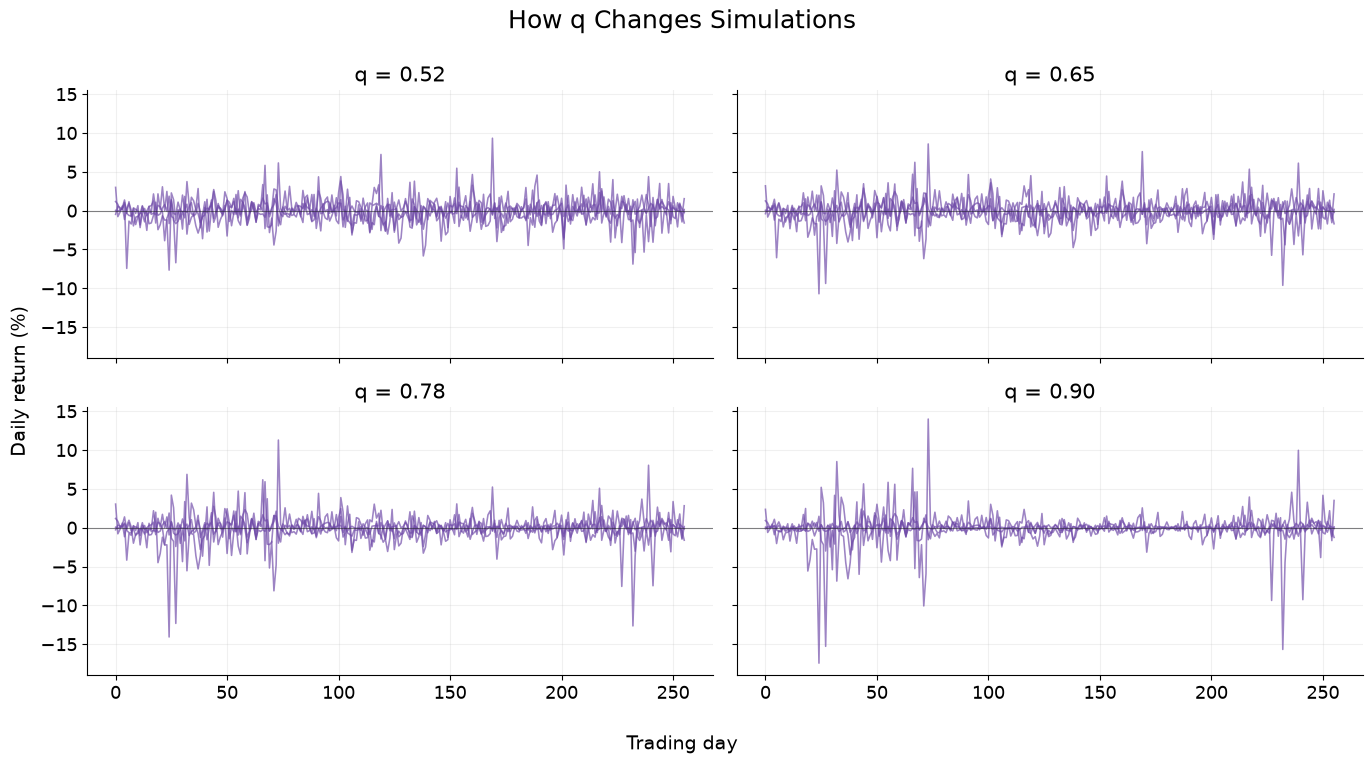

In [4]:
prior_data = model.simulate(3_000, seed=42, prior=model.PRIOR)
prior_returns = prior_data["returns"]

fig = plots.plot_q_turbulence(model.q_scenarios((0.52, 0.65, 0.78, 0.90), seed=42))
_ = viz.save_figure(fig, "01_prior_q_turbulence.png", FIGURES_DIR)

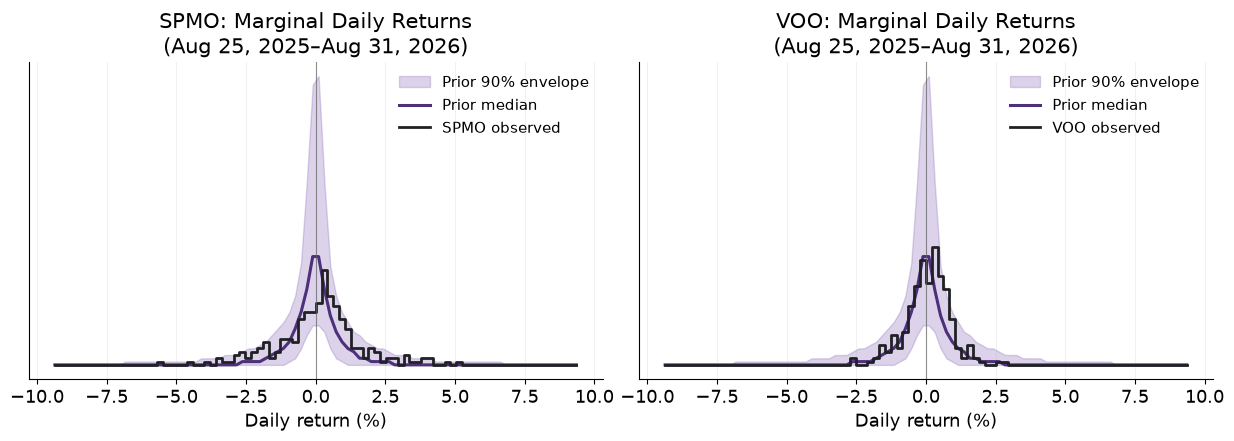

In [5]:
fig = plots.plot_marginal_return_histograms(100 * prior_returns, 100 * observed_window, tickers=TICKERS)
_ = viz.save_figure(fig, "02_prior_marginal_returns.png", FIGURES_DIR)

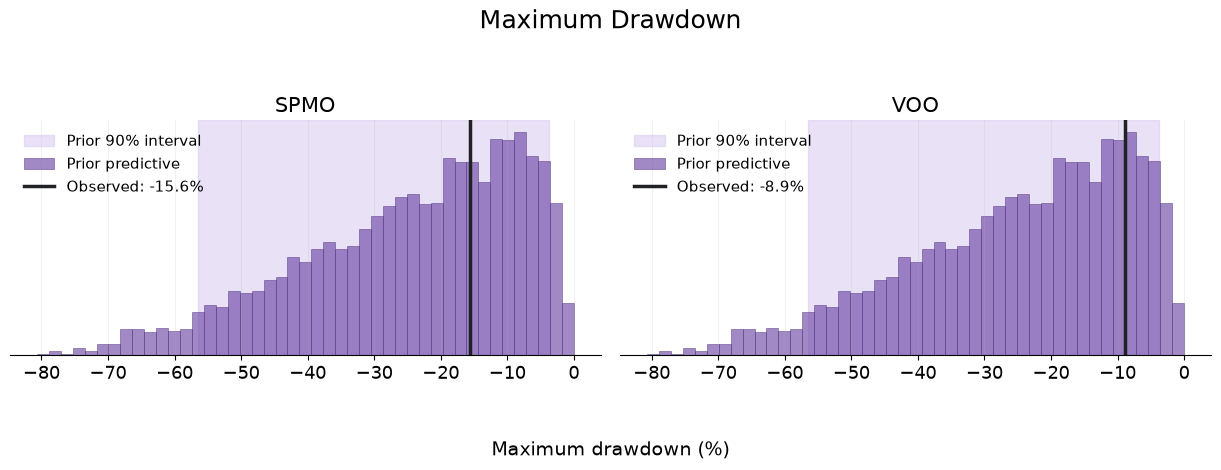

In [6]:
prior_stats = stats.statistics(prior_returns)
observed_stats = stats.statistics(observed_window.to_numpy().T)
observed_stats.index = TICKERS

fig = plots.plot_max_drawdown_checks(prior_stats, observed_stats, tickers=TICKERS)
_ = viz.save_figure(fig, "03_prior_max_drawdown.png", FIGURES_DIR)

In [7]:
envelope = stats.pushforward_envelope_table(prior_stats, observed_stats).rename(
    columns={"observed_pct": "observed", "prior_q05_pct": "prior_q05", "prior_q95_pct": "prior_q95"})
envelope.style.format(precision=2)

,ticker,stat,observed,prior_q05,prior_q95,inside_prior_90pct_band
0,SPMO,mean_pct,0.11,-0.29,0.28,True
1,SPMO,volatility_pct,1.52,0.41,2.40,True
2,SPMO,avg_abs_return_pct,1.10,0.27,1.53,True
3,SPMO,q01_pct,-3.63,-6.66,-0.97,True
4,SPMO,q05_pct,-2.60,-3.40,-0.43,True
5,SPMO,q95_pct,2.72,0.44,3.41,True
6,SPMO,q99_pct,4.02,1.03,6.59,True
7,SPMO,es05_pct,-3.35,-5.58,-0.88,True
8,SPMO,max_drawdown_pct,-15.64,-56.48,-3.71,True
9,SPMO,terminal_wealth,1.27,0.46,2.03,True


## 3. Amortized inference

Constraints are inverted by the adapter: all posterior draws are in original units.
$\mu$ stays unbounded. The FusionTransformer receives raw decimal returns, without per-window normalization or extra context.

In [8]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .constrain("sigma_bar", lower=model.PRIOR.sigma_low, upper=model.PRIOR.sigma_high)
    .constrain("q", lower=model.PRIOR.q_low, upper=model.PRIOR.q_high)
    .constrain("nu", lower=model.PRIOR.nu_low, upper=model.PRIOR.nu_high)
    .concatenate(model.PARAMETER_NAMES, into="inference_variables")
    .as_time_series("returns")
    .rename("returns", "summary_variables")
)

inference_network = bf.networks.CouplingFlow(transform="spline", depth=4)

summary_network = bf.networks.FusionTransformer(dropout=0.1)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=summary_network,
    inference_network=inference_network,
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


In [9]:
training_data = model.simulate(100_000)
validation_data = model.simulate(500)

In [10]:
history = workflow.fit_offline(
    data=training_data, 
    validation_data=validation_data, 
    epochs=60, 
    batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - loss: 4.3586 - val_loss: 3.2882
Epoch 2/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.6832 - val_loss: 2.2700
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.3198 - val_loss: 1.9469
Epoch 4/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.1241 - val_loss: 1.8835
Epoch 5/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.0140 - val_loss: 1.7407
Epoch 6/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.9307 - val_loss: 1.8748
Epoch 7/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.8325 - val_loss: 1.6855
Epoch 8/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.7460 - val_loss: 1.4870
Epoch 9/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.6405 - val_loss: 1.3835
Epoch 10/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.5252 - val_loss: 1.2848
Epoch 11/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.4569 - val_loss: 1.1700
Epoch 12/60
782/782 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 9.37 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/univariate/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/univariate/model.keras")


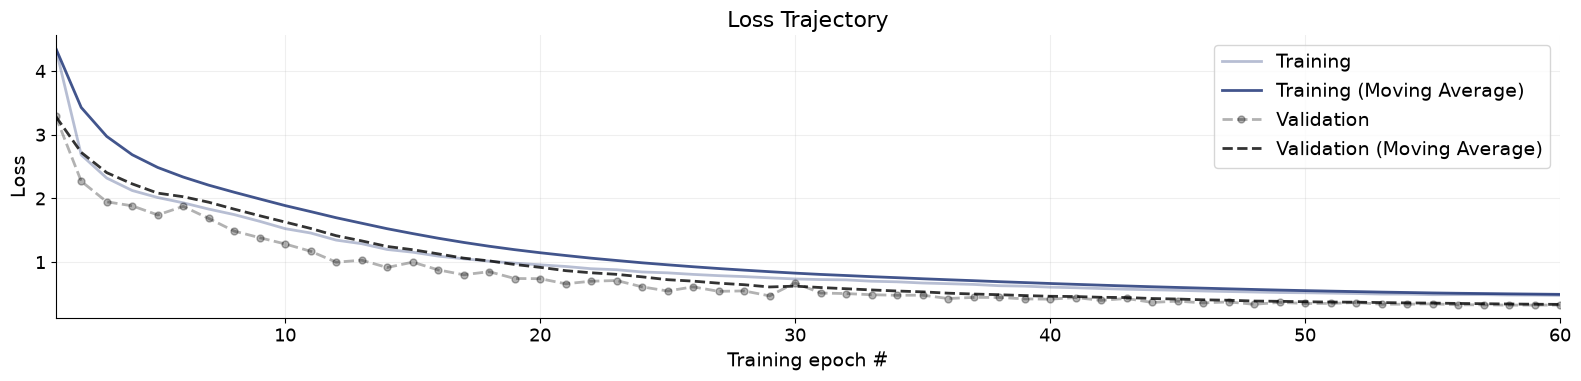

In [11]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "04_training_loss.png", FIGURES_DIR)

## 4. Parameter recovery and calibration

In [12]:
test_data = model.simulate(300)

In [13]:
validation_samples = workflow.sample(conditions=test_data, num_samples=1000)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 8.42 seconds.


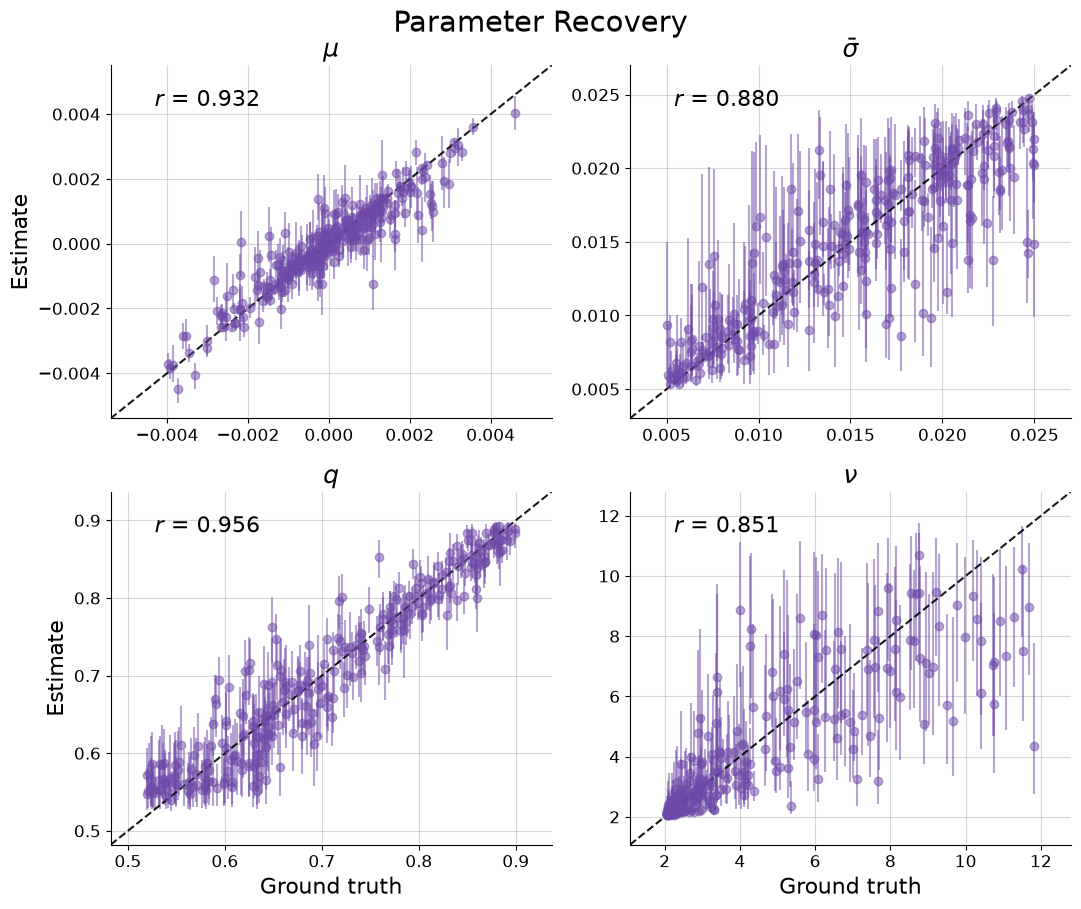

In [14]:
fig = viz.plot_recovery(validation_samples, test_data, model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "05_parameter_recovery.png", FIGURES_DIR)

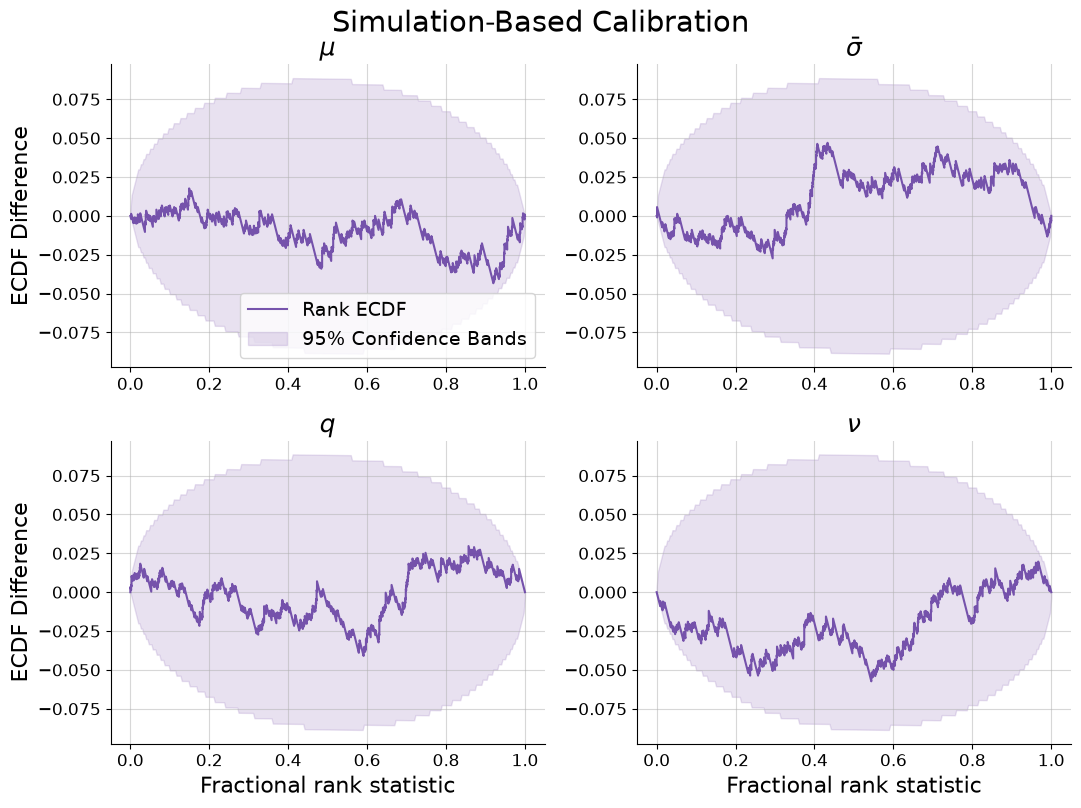

In [15]:
fig = viz.plot_calibration(validation_samples, test_data, model.PARAMETER_LABELS, alpha=0.2)
_ = viz.save_figure(fig, "06_simulation_based_calibration.png", FIGURES_DIR)

## 5. Posterior predictive checks

Fresh 256-day resimulations: 68% and 92% intervals, observed returns, wealth and marginal histograms.

In [16]:
observed_windows = observed_window.to_numpy().T
posterior = workflow.sample(conditions={"returns": observed_windows[..., None]}, num_samples=600)
posterior = model.stack_samples(posterior)

posterior_paths = model.posterior_resimulations(posterior)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 7.23 seconds.


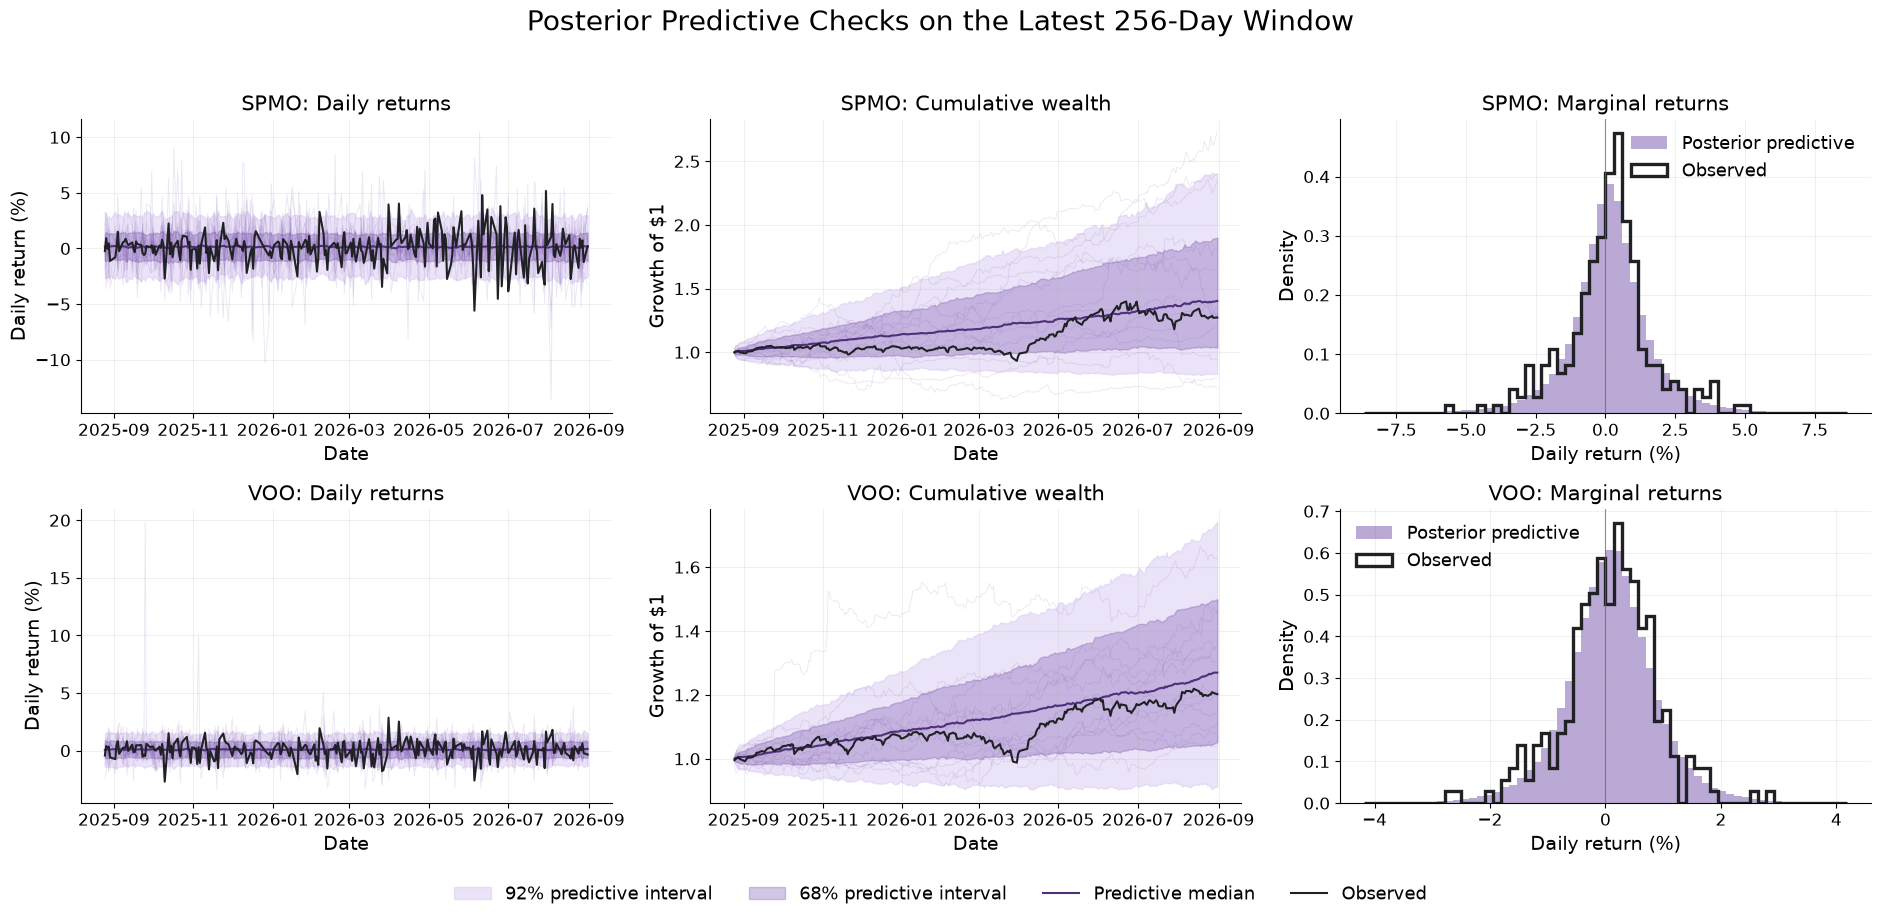

In [17]:
fig = plots.plot_posterior_predictive_checks(
    posterior_paths, observed_windows, [observed_window.index] * 2, tickers=TICKERS,
)

_ = viz.save_figure(fig, "07_posterior_predictive_checks.png", FIGURES_DIR)

## 6. Amortized decisions

20-day VaR and ES versus trailing historical simulation. Bands show variation across posterior
parameters (epistemic uncertainty) plus simulation noise (aleatoric uncertainty).

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 7.93 seconds.


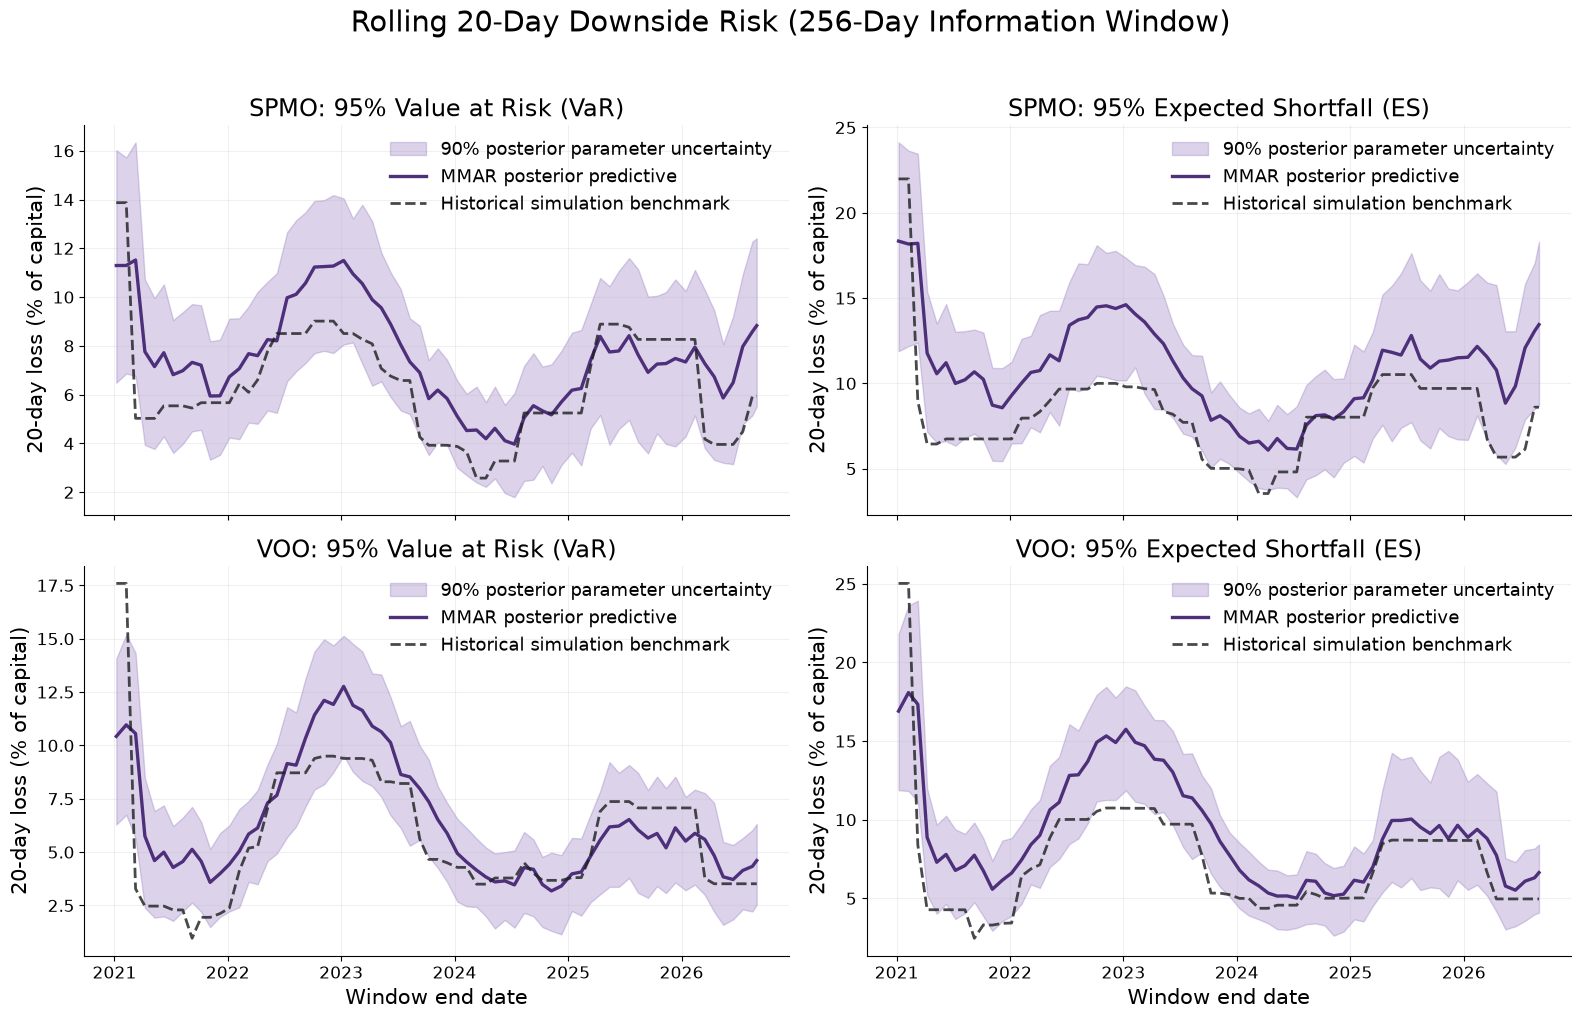

In [ ]:
rolling_windows, rolling_metadata = decisions.rolling_return_windows(observed_returns, TICKERS, step=21)
rolling_posteriors = workflow.sample(conditions={"returns": rolling_windows}, num_samples=500)
rolling_posteriors = model.stack_samples(rolling_posteriors)

decision_table = decisions.posterior_decision_table(
    posterior_samples=rolling_posteriors, 
    metadata=rolling_metadata,
    observed_returns=observed_returns,
    horizon=20, 
    n_parameter_draws=160, 
    n_replications=192,
)

decision_table.to_csv(FIGURES_DIR / "rolling_decisions.csv", index=False)

fig = plots.plot_rolling_risk(decision_table, tickers=TICKERS)
_ = viz.save_figure(fig, "08_rolling_var_es.png", FIGURES_DIR)

## 7. Deep ensembles

We can also train and compare multiple estimators.

In [19]:
workflow = bf.EnsembleWorkflow(
    inference_networks={
        "nf": bf.networks.CouplingFlow(depth=4, transform="spline"),
        "fm": bf.networks.FlowMatching(subnet_kwargs={"depth": (128,)*3}),
        "dm": bf.networks.DiffusionModel(subnet_kwargs={"depth": (128,)*3}),
    },
    summary_networks=bf.networks.FusionTransformer(),
    adapter=adapter,
    standardize="all"
)

In [20]:
history = workflow.fit_offline(
    data=training_data, 
    validation_data=validation_data,
    epochs=30,
    batch_size=128
)

INFO:bayesflow:EnsembleIndexedDataset: ensemble_size=3, batch_size=128, num_samples=100000, data_reuse=1.0 -> reduction_factor=1.00, window_size=100000, steps_per_epoch=782, drop_last=False. Overlap is enforced at the subdataset level (member-specific windows into the global index pool).
INFO:bayesflow:Fitting on dataset instance of EnsembleDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - dm/loss: 0.2579 - fm/loss: 0.9191 - loss: 4.1545 - nf/loss: 2.9774 - val_dm/loss: 0.3098 - val_fm/loss: 0.9654 - val_loss: 3.8047 - val_nf/loss: 2.5296
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2398 - fm/loss: 0.9631 - loss: 3.9520 - nf/loss: 2.7491 - val_dm/loss: 0.2386 - val_fm/loss: 0.7963 - val_loss: 3.0114 - val_nf/loss: 1.9765
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2298 - fm/loss: 0.8535 - loss: 3.5200 - nf/loss: 2.4367 - val_dm/loss: 0.2426 - val_fm/loss: 0.7846 - val_loss: 3.0147 - val_nf/loss: 1.9875
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.1940 - fm/loss: 0.9137 - loss: 3.2198 - nf/loss: 2.1122 - val_dm/loss: 0.2667 - val_fm/loss: 0.8159 - val_loss: 3.1317 - val_nf/loss: 2.0491
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2094 - fm/loss: 0.8185 - loss: 3.0975 - nf/loss: 2.0696 - val_dm/loss: 0.2600 - val_fm/loss: 0.9625 -

INFO:bayesflow:Training completed in 14.03 minutes.


In [21]:
samples = workflow.sample(
    conditions=test_data, 
    num_samples=1000,
    batch_size=20,
    merge_members=False
)

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.84 minutes.


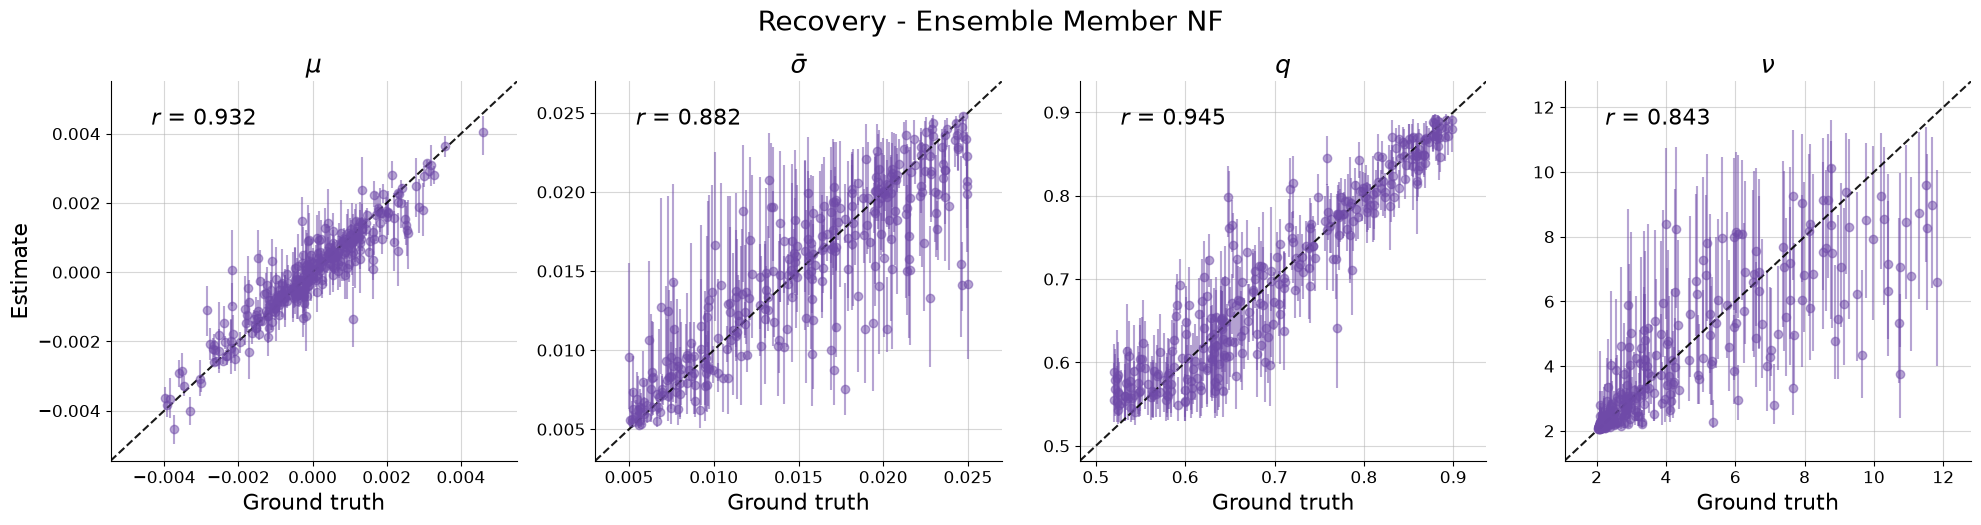

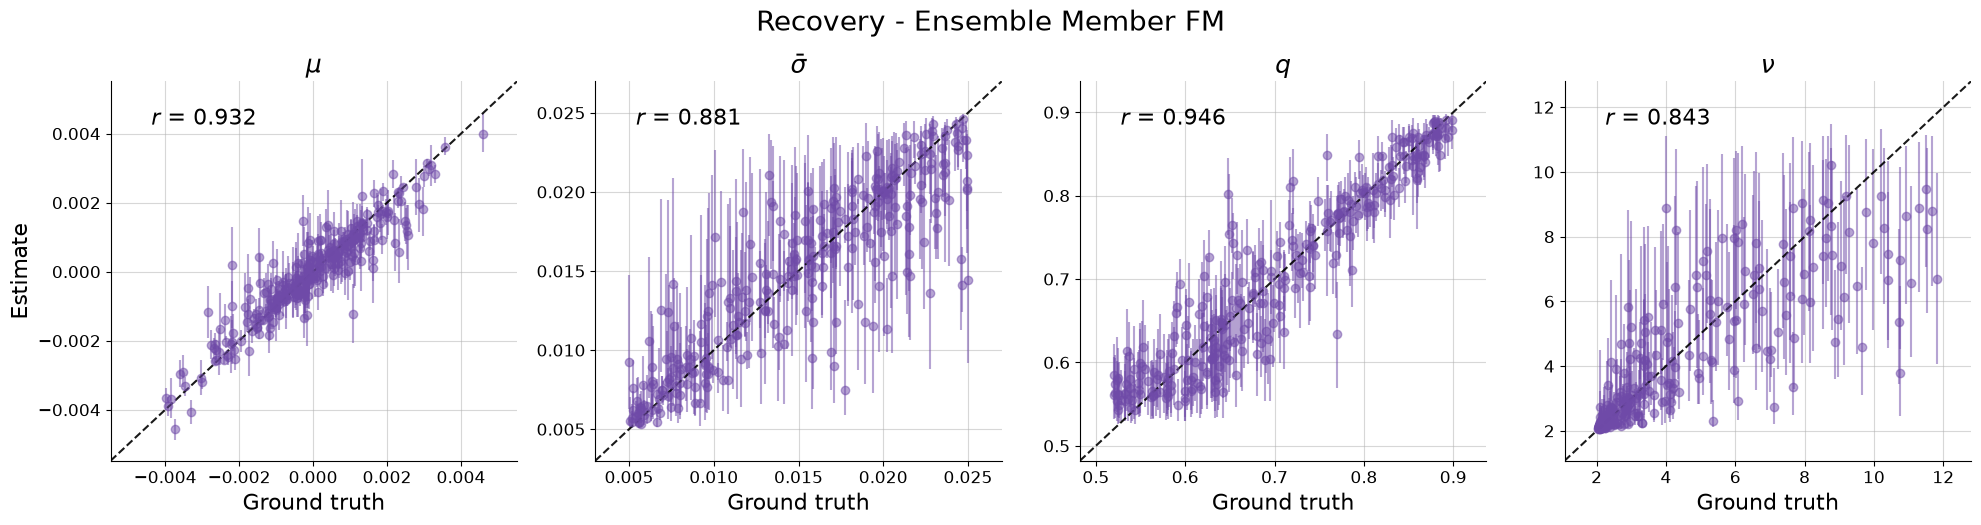

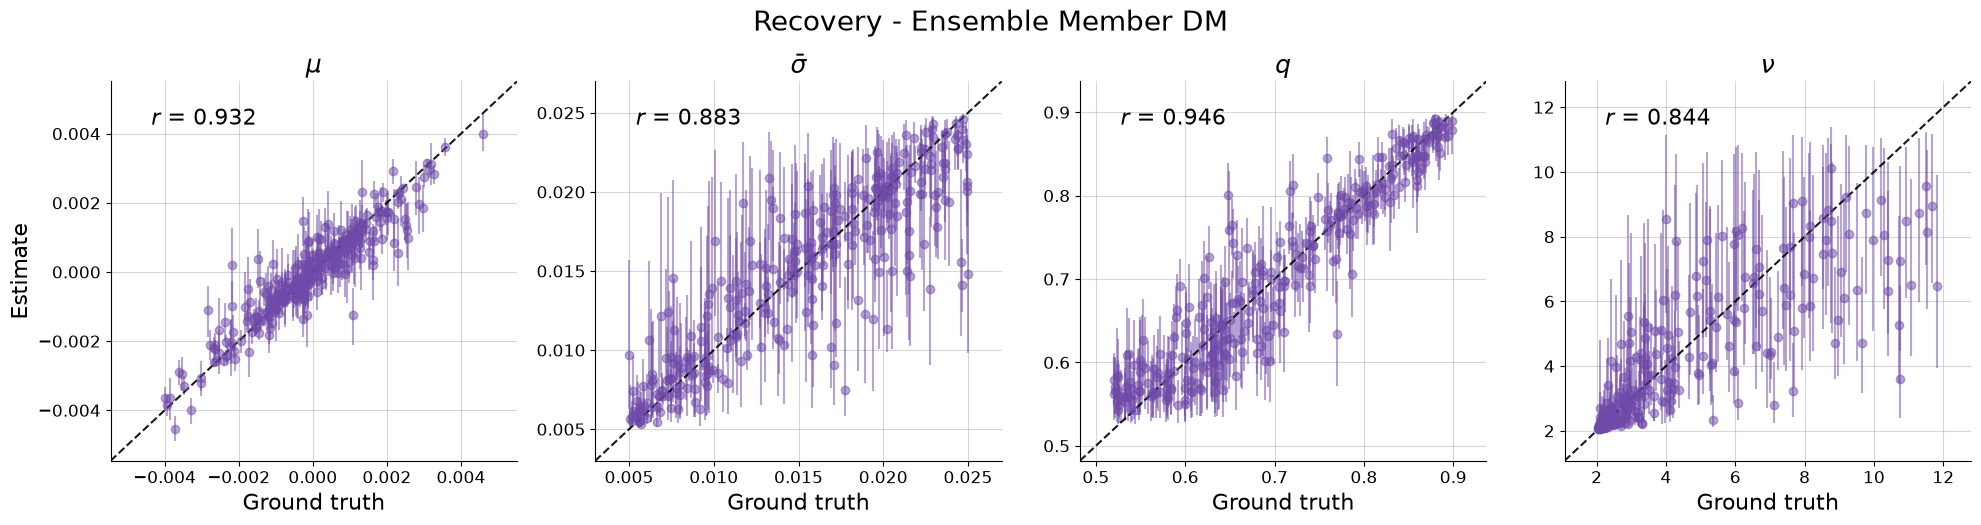

In [32]:
for k, v in samples.items():
    fig = bf.diagnostics.recovery(
        estimates=samples[k],
        targets=test_data,
        uncertainty_agg_kwargs={"prob": 0.68},
        color=viz.PREDICTION_PURPLE,
        variable_names=model.PARAMETER_LABELS
    )
    fig.suptitle(f"Recovery - Ensemble Member {k.upper()}", fontsize=20, y=1.05)

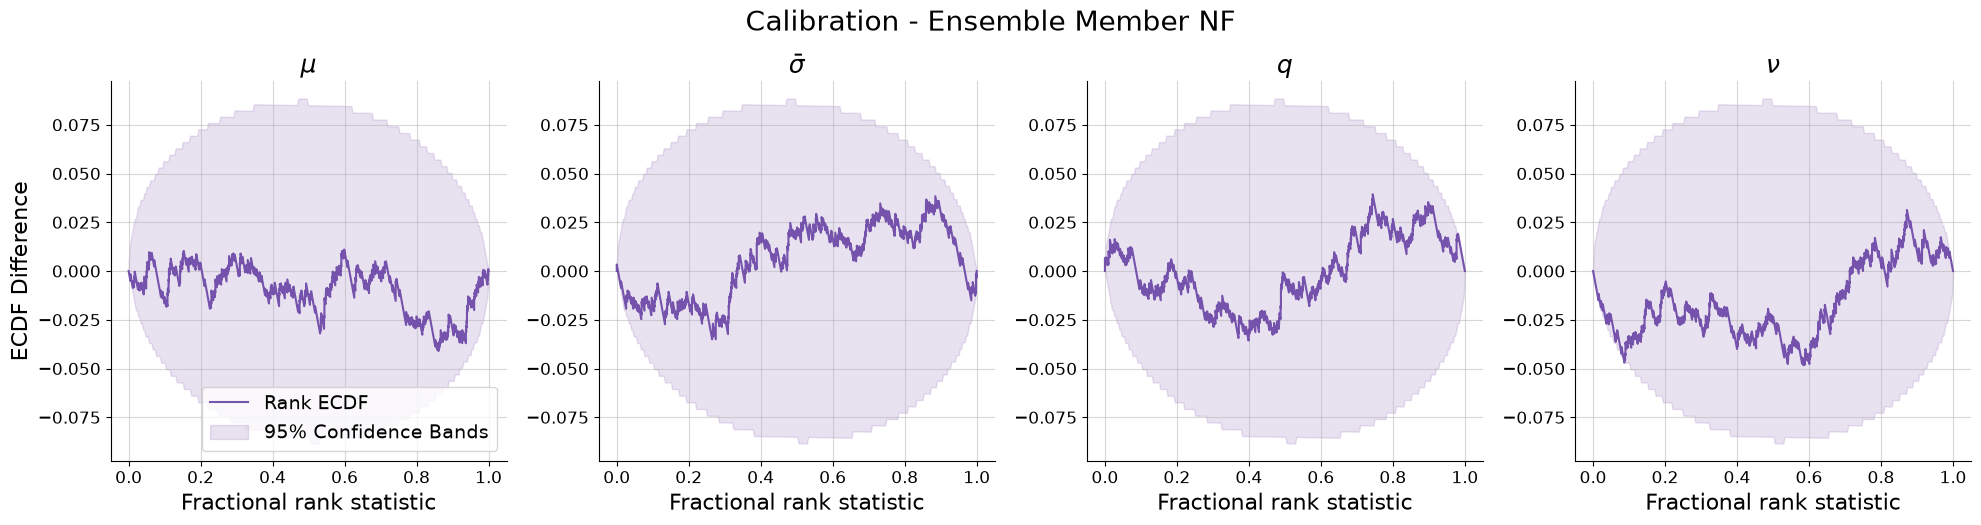

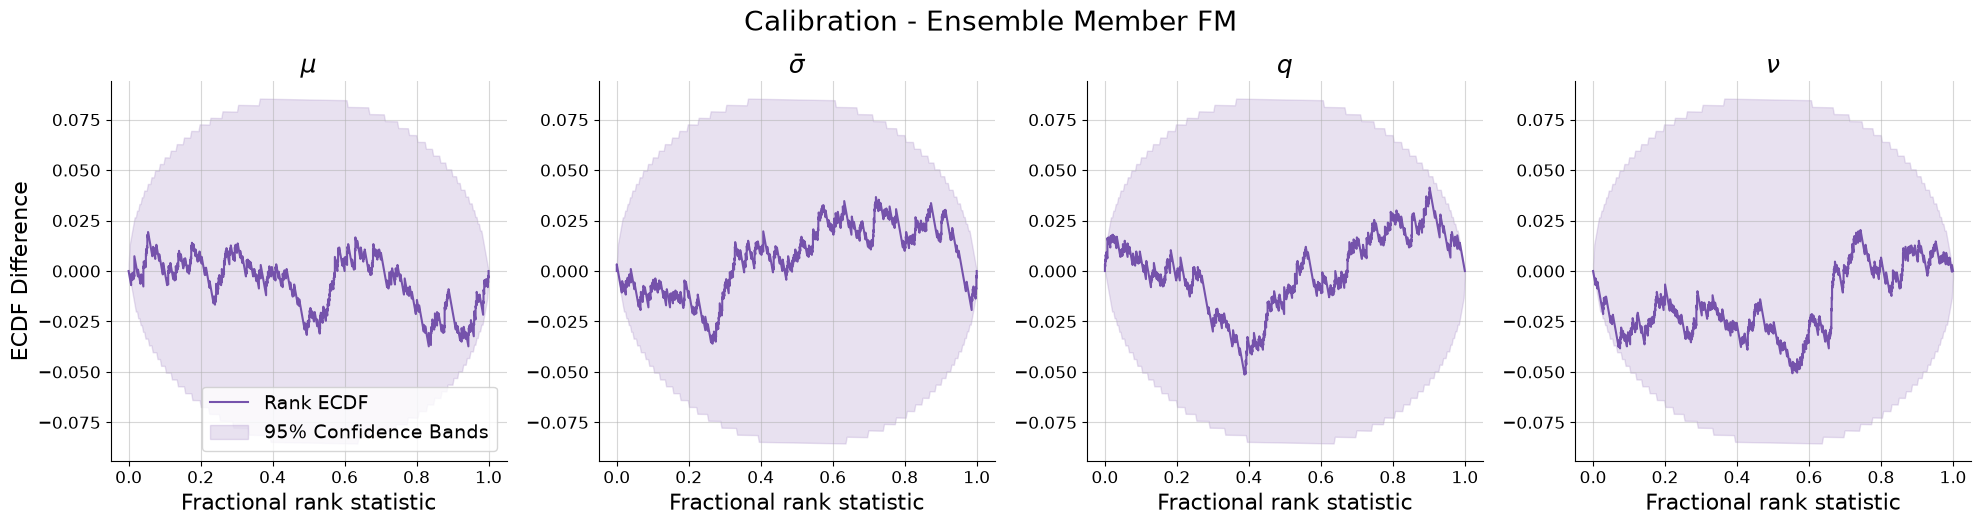

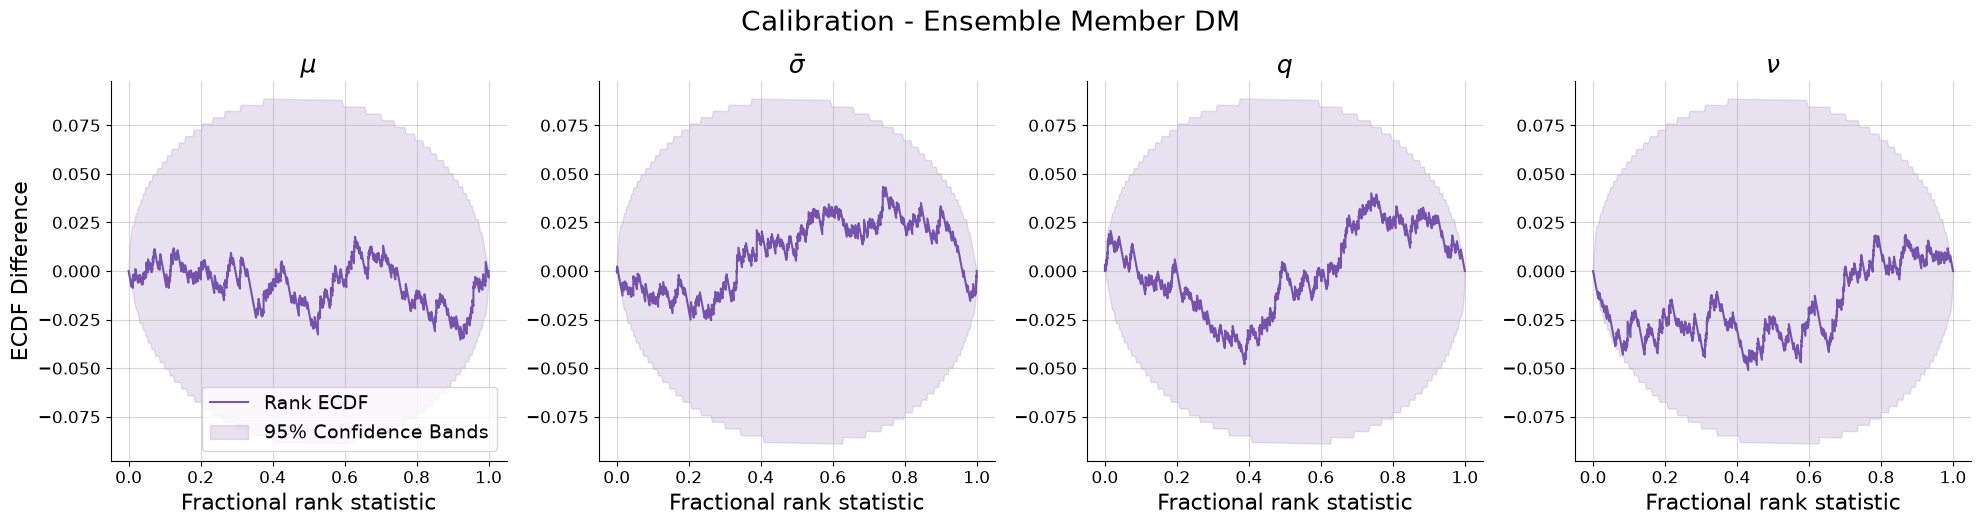

In [31]:
for k, v in samples.items():
    fig = bf.diagnostics.calibration_ecdf(
        estimates=samples[k],
        targets=test_data,
        uncertainty_agg_kwargs={"prob": 0.68},
        rank_ecdf_color=viz.PREDICTION_PURPLE,
        fill_color=viz.CALIBRATION_BAND_COLOR,
        variable_names=model.PARAMETER_LABELS
    )
    fig.suptitle(f"Calibration - Ensemble Member {k.upper()}", fontsize=20, y=1.05)